# 2D Deep Learning Models for Impact Echo Classification

This notebook implements the ResNet (Residual Network) Convolutional Neural Network.

## ResNet (Transfer Learning)
ResNet utilizes "skip connections" to allow gradients to flow through extremely deep networks 
without vanishing. We use Transfer Learning by loading weights pre-trained on ImageNet, freezing 
the deep feature extractors, and modifying the final fully connected (`fc`) layer for our 2-class problem.

* **Architecture:** ResNet-50 (Pre-trained `IMAGENET1K_V1` weights)
* **Input Size:** 224 x 224 x 3
* **Optimizer:** SGDM
* **Batch Size:** 50
* **Max Epochs:** 25
* **Learning Rate:** 1e-4

In [16]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

# Hardware setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU



In [17]:
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    # Process Defected (Class 1)
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    # Process Sound (Class 0)
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}")

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512


## ResNet Dataset & Model Setup
Like GoogLeNet, ResNet uses a `224x224` input size. We will load the `resnet50` architecture, 
freeze the residual blocks, and replace the final classification layer.

The article describes the retrained head as four logical stages: ReLU, FC, Softmax, and classification output. 
In this PyTorch transfer learning implementation, those map to the final classifier block, where only the `fc` layer contains trainable parameters; the activation and softmax steps are part of the output path rather than separate learnable parameter tensors.

In [18]:
class SpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        # ImageNet standardization values
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = voltage - np.mean(voltage)
        
        f, t, Zxx = signal.stft(voltage, fs=200000, nperseg=128, noverlap=64)
        spec_mag = np.abs(Zxx)
        spec_log = 10 * np.log10(spec_mag + 1e-8)
        
        spec_norm = (spec_log - np.min(spec_log)) / (np.max(spec_log) - np.min(spec_log) + 1e-8)
        
        # ResNet strictly expects 224x224 inputs
        spec_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        resized_spec = F.interpolate(spec_tensor, size=(224, 224), mode='bilinear', align_corners=False)
        
        rgb_spec = resized_spec.squeeze(0).repeat(3, 1, 1)
        final_spec = self.normalize(rgb_spec)
        
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return final_spec, label_tensor

def get_resnet_tl(num_classes=2):
    # Load pre-trained ResNet-50 weights
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # FREEZE the feature extraction layers
    for param in model.parameters():
        param.requires_grad = False
        
    # Fine-tune the final ResNet block plus a new classifier head.
    # This gives the model capacity to adapt ImageNet features to the Impact Echo defect domain.
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(1024, num_classes)
    )

    return model

In [ ]:
# 3. Training Protocol (ResNet TL)
# =========================================================
# Hyperparameters
import pickle

EPOCHS = 25 # Note: Table 3 in the paper used 25 for ResNet.
BATCH_SIZE = 50
LR = 3e-4   # it is better than 1e-4 of Table 3for ResNet TL

resnet_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training ResNet (TL): Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    # Split data (Leave-One-Specimen-Out)
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    # Define files and labels
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = SpectrogramDataset(train_files, train_labels)
    test_dataset = SpectrogramDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = get_resnet_tl().to(device)
    
    # Dynamic Class Weighting to handle the Sound vs Defected imbalance (~3:1)
    num_sound = np.sum(train_labels == 0)
    num_defected = np.sum(train_labels == 1)
    weight_ratio = num_sound / num_defected
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # CRITICAL FOR TL: We filter parameters to ONLY pass the unfrozen classifier layers to the optimizer
    optimizer = optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        momentum=0.9,
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # Gradient clipping as a safety net
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            optimizer.step()
            running_loss += loss.item()

            # Record accuracy after each training iteration (batch update).
            model.eval()
            iter_preds = []
            iter_targs = []
            with torch.no_grad():
                for val_inputs, val_targets in test_loader:
                    val_inputs, val_targets = val_inputs.to(device, non_blocking=True), val_targets.to(device, non_blocking=True)
                    val_outputs = model(val_inputs)
                    _, val_preds = torch.max(val_outputs, 1)
                    iter_preds.extend(val_preds.cpu().numpy())
                    iter_targs.extend(val_targets.cpu().numpy())

            if len(iter_preds) > 0:
                cm = confusion_matrix(iter_targs, iter_preds, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                iter_acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
                iteration_accuracies[test_slab].append(iter_acc * 100)

            model.train()

        epoch_loss = running_loss / len(train_loader)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {epoch_loss:.4f}")
        scheduler.step(epoch_loss)
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    tn, fp, fn, tp = confusion_matrix(all_targs, all_preds, labels=[0, 1]).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    resnet_metrics['ACC'].append(acc)
    resnet_metrics['TPR'].append(tpr)
    resnet_metrics['TNR'].append(tnr)
    resnet_metrics['F1'].append(f1)

history_path = os.path.join(os.getcwd(), "resnet_tl_iteration_accuracies.pkl")
with open(history_path, "wb") as f:
    pickle.dump(iteration_accuracies, f)
print(f"Saved training history to {history_path}")

total_time = time.time() - total_start_time
# 4. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total ResNet (TL) Training Time: {total_time/60:.2f} minutes")
print("=== Overall ResNet (TL) Performance Metrics ===")

for metric, values in resnet_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)

    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")


--- Training ResNet (TL): Holding out Slab 1 for Testing ---
  Epoch [01/25] - Loss: 0.7025
  Epoch [05/25] - Loss: 0.6484
  Epoch [10/25] - Loss: 0.4047
  Epoch [15/25] - Loss: 0.1018
  Epoch [20/25] - Loss: 0.0253
  Epoch [25/25] - Loss: 0.0127
  > Test Slab 1 Results - ACC: 0.89 | TPR: 0.59 | TNR: 0.99 | F1: 0.73
  > Fold completed in 1110.9 seconds.

--- Training ResNet (TL): Holding out Slab 2 for Testing ---
  Epoch [01/25] - Loss: 0.7041
  Epoch [05/25] - Loss: 0.6419
  Epoch [10/25] - Loss: 0.4084
  Epoch [15/25] - Loss: 0.1069
  Epoch [20/25] - Loss: 0.0234
  Epoch [25/25] - Loss: 0.0160
  > Test Slab 2 Results - ACC: 0.89 | TPR: 0.72 | TNR: 0.95 | F1: 0.77
  > Fold completed in 1145.9 seconds.

--- Training ResNet (TL): Holding out Slab 3 for Testing ---
  Epoch [01/25] - Loss: 0.6973
  Epoch [05/25] - Loss: 0.6470
  Epoch [10/25] - Loss: 0.4241
  Epoch [15/25] - Loss: 0.1149
  Epoch [20/25] - Loss: 0.0301
  Epoch [25/25] - Loss: 0.0114
  > Test Slab 3 Results - ACC: 0.87 | T


Generating Accuracy vs Iteration plot for ResNet (TL)...
Loaded accuracy history from c:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\resnet_tl_iteration_accuracies.pkl
History lengths per slab:


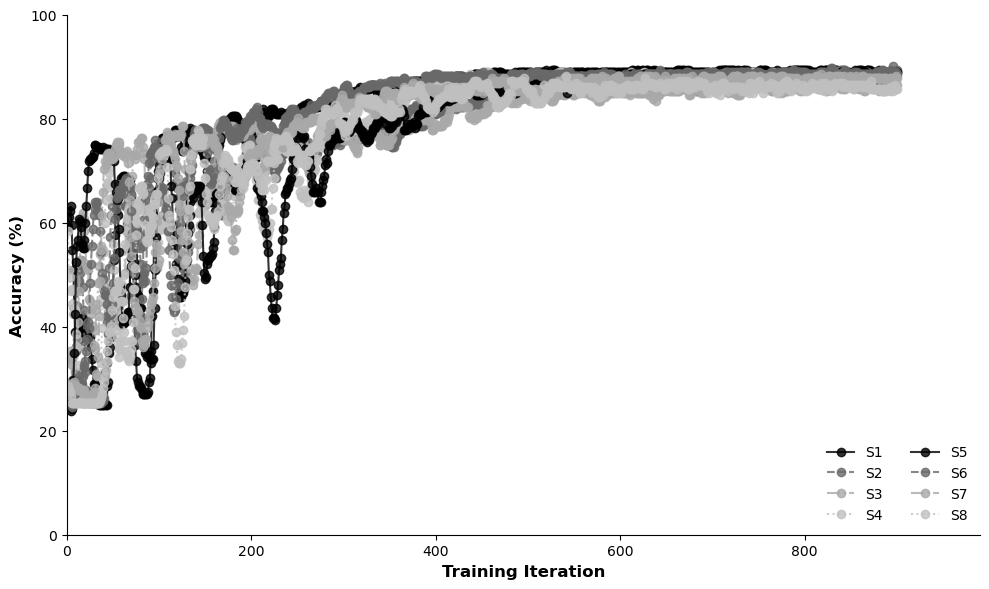

Plot saved successfully as 'resnet_tl_accuracy_vs_iteration.png'.


In [23]:
# =========================================================
# 5. Plotting Accuracy vs Iteration
# =========================================================
import os
import pickle
import matplotlib.pyplot as plt

print("\nGenerating Accuracy vs Iteration plot for ResNet (TL)...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

history_path = os.path.join(os.getcwd(), "resnet_tl_iteration_accuracies.pkl")
if os.path.exists(history_path):
    with open(history_path, "rb") as f:
        iteration_accuracies = pickle.load(f)
    print(f"Loaded accuracy history from {history_path}")
    print("History lengths per slab:")

else:
    iteration_accuracies = {slab: [] for slab in range(1, 9)}
 
has_data = False
for slab_id in range(1, 9):
    acc_data = iteration_accuracies.get(slab_id, [])
    if len(acc_data) == 0:
        continue
    has_data = True
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5, marker='o')

ax.set_xlabel('Training Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

max_len = max((len(v) for v in iteration_accuracies.values()), default=0)
if max_len == 0:
    print("No per-iteration accuracy data found; skipping plot.")
else:
    ax.set_xlim(0, max_len * 1.1)

if has_data:
    ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('resnet_tl_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'resnet_tl_accuracy_vs_iteration.png'.")
